In [317]:
# Librerías necesarias
import vitaldb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [318]:
cases = pd.read_csv("../data/raw/cases.csv")
labs  = pd.read_csv("../data/raw/labs.csv")
trks  = pd.read_csv("../data/raw/trks.csv")

In [319]:
cases.head()

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


In [320]:
labs.head()

,caseid,dt,name,result
0,1,594470,alb,2.9
1,1,399575,alb,3.2
2,1,12614,alb,3.4
3,1,137855,alb,3.6
4,1,399575,alt,12.0


In [321]:
trks.head()

,caseid,tname,tid
0,1,BIS/BIS,fd869e25ba82a66cc95b38ed47110bf4f14bb368
1,1,BIS/EEG1_WAV,0aa685df768489a18a5e9f53af0d83bf60890c73
2,1,BIS/EEG2_WAV,ad13b2c39b19193c8ae4a2de4f8315f18d61a57e
3,1,BIS/EMG,2525603efe18d982764dbca457affe7a45e766a9
4,1,BIS/SEF,1c91aec859304840dec75acf4a35da78be0e8ef0


In [322]:
# Revisar columnas de cada CSV
print("Columns en cases.csv:", cases.columns.tolist())
print("Columns en labs.csv:", labs.columns.tolist())
print("Columns en trks.csv:", trks.columns.tolist())

Columns en cases.csv: ['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend', 'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn', 'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr', 'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2', 'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl', 'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid', 'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn', 'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca']
Columns en labs.csv: ['caseid', 'dt', 'name', 'result']
Columns en trks.csv: ['ca

In [323]:
# Ver todos los tipos de prueba en labs.csv
labs['name'].unique()

<StringArray>
[  'alb',   'alt',  'aptt',   'ast',   'bun',    'cl',    'cr',   'crp',
   'fib',   'gfr',  'gluc',    'hb',  'hco3',   'hct',   'ica',     'k',
   'lac',    'na',  'pco2',    'ph',   'plt',   'po2',   'pt%', 'ptinr',
 'ptsec',  'sao2',  'tbil', 'tprot',   'wbc',    'be',     'p',   'esr',
   'ccr',  'ammo']
Length: 34, dtype: str

In [324]:
labs_glucose = labs[labs['name'] == 'gluc']
labs_glucose.shape

(35358, 4)

In [325]:
trks_ppg = trks[trks['tname'] == 'SNUADC/PLETH']
trks_ppg.shape

(6157, 3)

In [326]:
columnas_deseadas = ['caseid', 'age', 'sex', 'bmi']
cases_clean = cases[columnas_deseadas]
cases_clean.shape

(6388, 4)

In [327]:
labs_and_cases = pd.merge(labs_glucose, cases_clean, on='caseid', how='inner')
labs_and_cases.shape

(35358, 7)

In [328]:
labs_cases_trks = pd.merge(trks_ppg, labs_and_cases, on='caseid', how='inner')
labs_cases_trks.shape

(29713, 9)

In [329]:
labs_cases_trks.rename(columns={'dt': 'bgl_timestamp_sec', 'result': 'bgl_value_mg_dL', 'tid': 'ppg_track_tid'}, inplace=True)
labs_cases_trks.head()

,caseid,tname,ppg_track_tid,bgl_timestamp_sec,name,bgl_value_mg_dL,age,sex,bmi
0,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,3060,gluc,154.0,77.0,M,26.3
1,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,4628,gluc,182.0,77.0,M,26.3
2,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,12614,gluc,198.0,77.0,M,26.3
3,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,8921,gluc,210.0,77.0,M,26.3
4,2,SNUADC/PLETH,8dc8fb6a62bf86f5117e4b5ea679f061c30b8640,5857898,gluc,114.0,54.0,M,19.6


In [330]:
# Guardar el DataFrame final en un nuevo CSV
labs_cases_trks.to_csv("../data/raw/processed/BGL_PPG_map.csv", index=False)

PRUEBA PILOTO CON 1 CASO

In [331]:
# Cargar mapa maestro
map_path = "../data/raw/processed/BGL_PPG_map.csv"
bgl_ppg_map = pd.read_csv(map_path)

bgl_ppg_map.head()

,caseid,tname,ppg_track_tid,bgl_timestamp_sec,name,bgl_value_mg_dL,age,sex,bmi
0,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,3060,gluc,154.0,77.0,M,26.3
1,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,4628,gluc,182.0,77.0,M,26.3
2,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,12614,gluc,198.0,77.0,M,26.3
3,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,8921,gluc,210.0,77.0,M,26.3
4,2,SNUADC/PLETH,8dc8fb6a62bf86f5117e4b5ea679f061c30b8640,5857898,gluc,114.0,54.0,M,19.6


In [332]:
case_piloto = bgl_ppg_map['caseid'].iloc[0]
map_piloto = bgl_ppg_map[bgl_ppg_map['caseid'] == case_piloto]
map_piloto.head()

,caseid,tname,ppg_track_tid,bgl_timestamp_sec,name,bgl_value_mg_dL,age,sex,bmi
0,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,3060,gluc,154.0,77.0,M,26.3
1,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,4628,gluc,182.0,77.0,M,26.3
2,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,12614,gluc,198.0,77.0,M,26.3
3,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,8921,gluc,210.0,77.0,M,26.3


In [333]:
#Elegimos el track_tid del piloto para analizar su señal PPG
ppg_tid = map_piloto['tname'].iloc[0]
# Cargar la señal PPG del piloto usando vitaldb
track_names = [ppg_tid]
vf = vitaldb.VitalFile(case_piloto, track_names)

#Se convierte la señal a un array de numpy
#Se reduce la frecuencia de muestreo a 100 Hz para facilitar el análisis
ppg_samples = vf.to_numpy(track_names, 1/100)

#Número de muestras en la señal PPG del piloto
ppg_samples.shape

(1154110, 1)

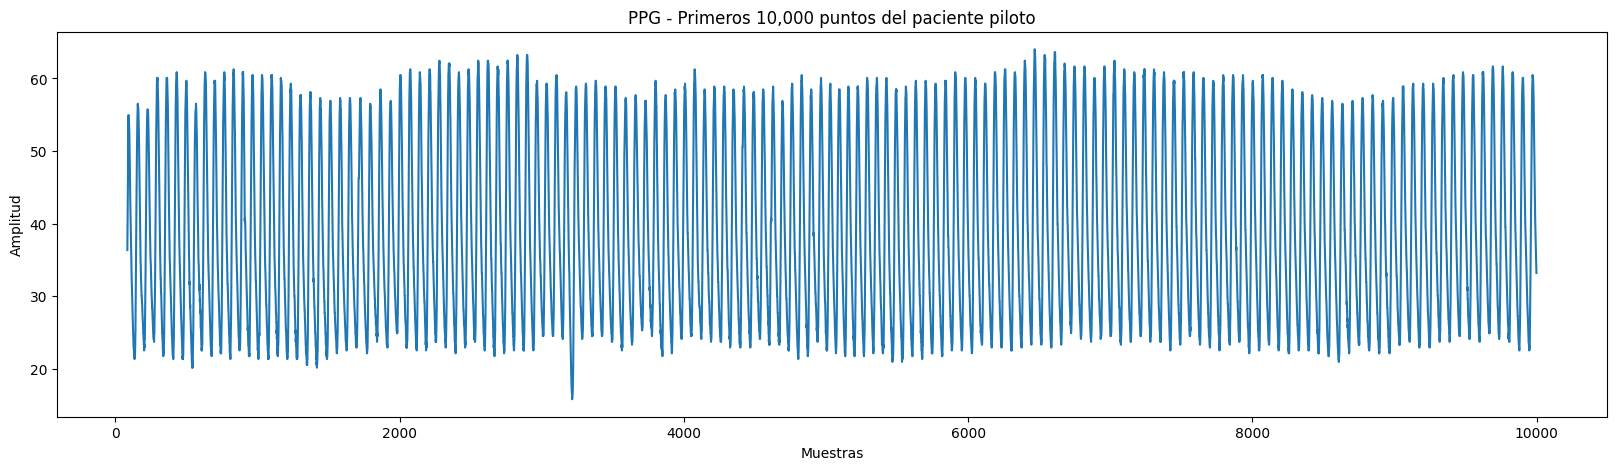

In [334]:
plt.figure(figsize=(20,5))
plt.plot(ppg_samples[:10000, 0])
plt.title("PPG - Primeros 10,000 puntos del paciente piloto")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

In [335]:
import pandas as pd
import numpy as np

# Señal cruda como vector 1D
ppg_raw = ppg_samples[:, 0]

# Convertimos a Series para poder interpolar fácilmente
ppg_clean = pd.Series(ppg_raw)

# Interpolación lineal de NaN internos
ppg_clean = ppg_clean.interpolate(method='linear')

# Si hubiera NaN al inicio o al final, los rellenamos
ppg_clean = ppg_clean.bfill().ffill()

# Volvemos a NumPy
ppg_clean = ppg_clean.to_numpy()

print("Tamaño señal limpia:", ppg_clean.shape)
print("NaN en señal limpia:", np.isnan(ppg_clean).sum())

Tamaño señal limpia: (1154110,)
NaN en señal limpia: 0


In [336]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Parámetros
fs = 100
lowcut = 0.5
highcut = 8
order = 3

# Frecuencia de Nyquist
nyquist = 0.5 * fs

# Normalizar las frecuencias de corte
low = lowcut / nyquist
high = highcut / nyquist

# Diseñar el filtro Butterworth pasa banda
b, a = butter(order, [low, high], btype='band')

# Aplicar el filtro
ppg_filtered = filtfilt(b, a, ppg_clean)

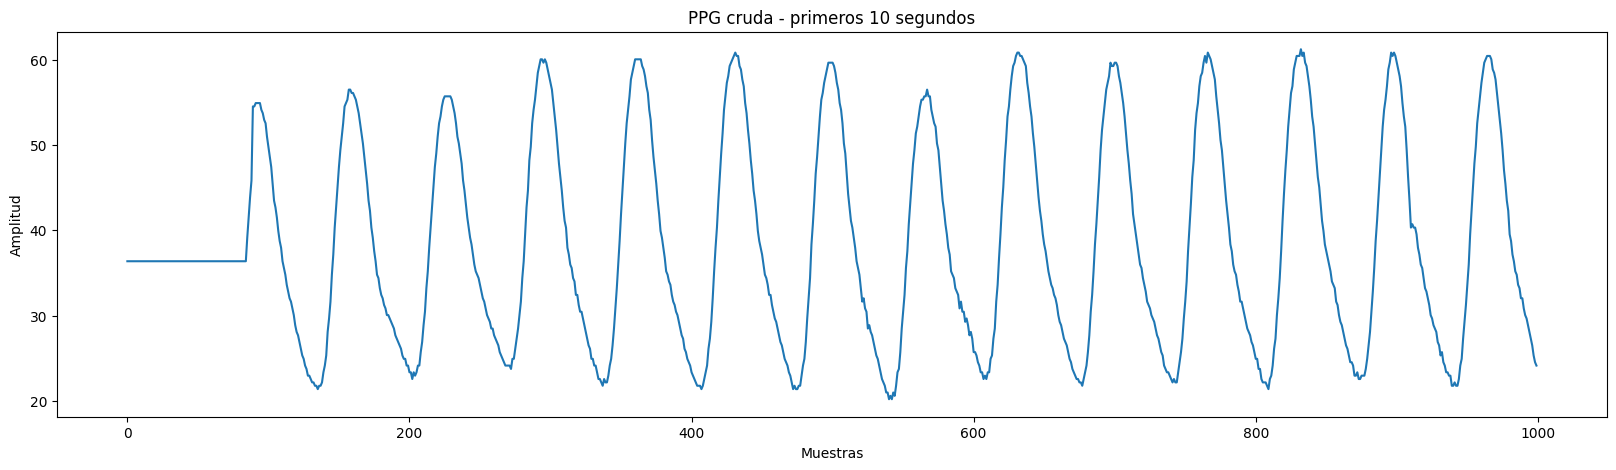

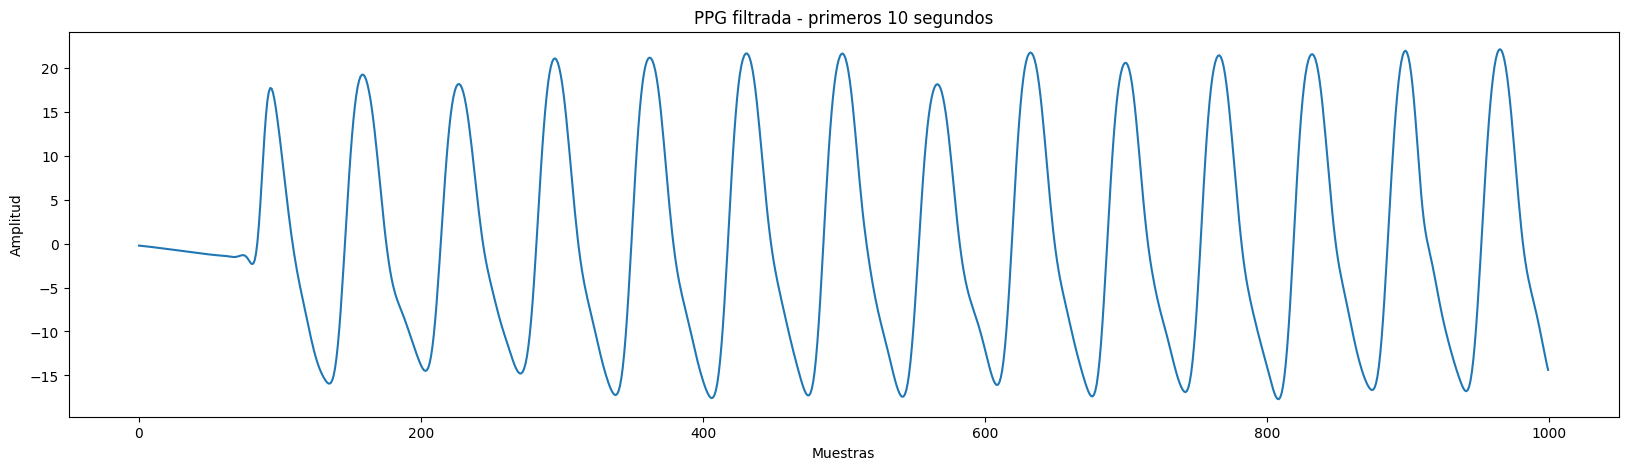

In [337]:
n = 1000  # 1000 muestras = 10 segundos a 100 Hz

plt.figure(figsize=(20, 5))
plt.plot(ppg_clean[:n])
plt.title("PPG cruda - primeros 10 segundos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

plt.figure(figsize=(20, 5))
plt.plot(ppg_filtered[:n])
plt.title("PPG filtrada - primeros 10 segundos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

In [338]:
print("Tamaño señal limpia:", ppg_clean.shape)
print("Tamaño señal filtrada:", ppg_filtered.shape)
print("NaN en señal filtrada:", np.isnan(ppg_filtered).sum())

Tamaño señal limpia: (1154110,)
Tamaño señal filtrada: (1154110,)
NaN en señal filtrada: 0


In [339]:
map_piloto.head()

,caseid,tname,ppg_track_tid,bgl_timestamp_sec,name,bgl_value_mg_dL,age,sex,bmi
0,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,3060,gluc,154.0,77.0,M,26.3
1,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,4628,gluc,182.0,77.0,M,26.3
2,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,12614,gluc,198.0,77.0,M,26.3
3,1,SNUADC/PLETH,9acbed98f1f15c7827ee3bcc55eaef19f861b824,8921,gluc,210.0,77.0,M,26.3


In [340]:
fila_piloto = map_piloto.iloc[0]
print("Información del paciente piloto:")
print(fila_piloto)

Información del paciente piloto:
caseid                                                      1
tname                                            SNUADC/PLETH
ppg_track_tid        9acbed98f1f15c7827ee3bcc55eaef19f861b824
bgl_timestamp_sec                                        3060
name                                                     gluc
bgl_value_mg_dL                                         154.0
age                                                      77.0
sex                                                         M
bmi                                                      26.3
Name: 0, dtype: object


In [341]:
# timestamp de la glucosa en segundos
timestamp_gluc = fila_piloto['bgl_timestamp_sec']

# calcular inicio y fin en segundos
inicio_seg = timestamp_gluc - 8*60
fin_seg    = timestamp_gluc + 8*60

# convertir a índices
inicio_idx = int(inicio_seg * 100)  # 100 Hz
fin_idx    = int(fin_seg * 100)

# cortar la ventana de 16 minutos 
ppg_window = ppg_filtered[inicio_idx:fin_idx]

print("Tamaño ventana en muestras:", ppg_window.shape)

Tamaño ventana en muestras: (96000,)


In [342]:
from scipy.signal import find_peaks

# Detectamos picos en la ventana de 16 min
# Ajustamos parámetros mínimos:
#   distance = 50 -> mínimo de 0.5 s entre picos a 100 Hz
#   height = None -> dejamos que detecte todos los picos positivos
peaks, _ = find_peaks(ppg_window, distance=50)

print(f"Número de picos detectados en 16 minutos: {len(peaks)}")
print(f"Primeros 10 picos: {peaks[:10]}")

Número de picos detectados en 16 minutos: 1352
Primeros 10 picos: [  4  65 125 185 246 305 365 424 483 541]


In [343]:
# Cada ventana = 100 muestras
window_size = 100

segments = []
for peak in peaks:
    start = peak - window_size//2 #0.5 segundos antes del pico
    end   = peak + window_size//2 #0.5 segundos después del pico
    # Verificar que la ventana está dentro de la señal
    if start >= 0 and end <= len(ppg_window):
        segment = ppg_window[start:end]
        segments.append(segment)

segments = np.array(segments)
print(f"Número de ventanas de 1 segundo válidas: {segments.shape[0]}")
print(f"Forma de cada segmento: {segments.shape[1]}")

Número de ventanas de 1 segundo válidas: 1350
Forma de cada segmento: 100


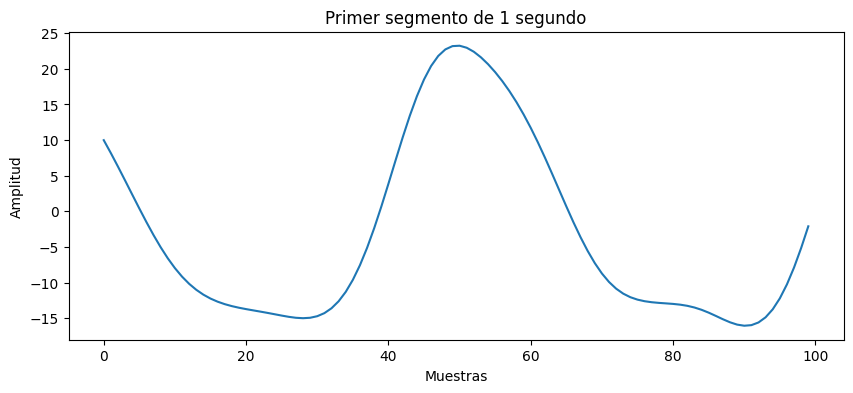

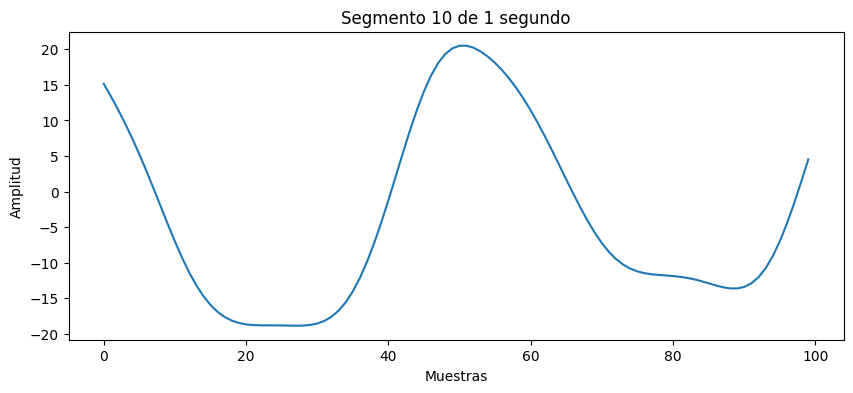

In [344]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(segments[0])
plt.title("Primer segmento de 1 segundo")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(segments[10])
plt.title("Segmento 10 de 1 segundo")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

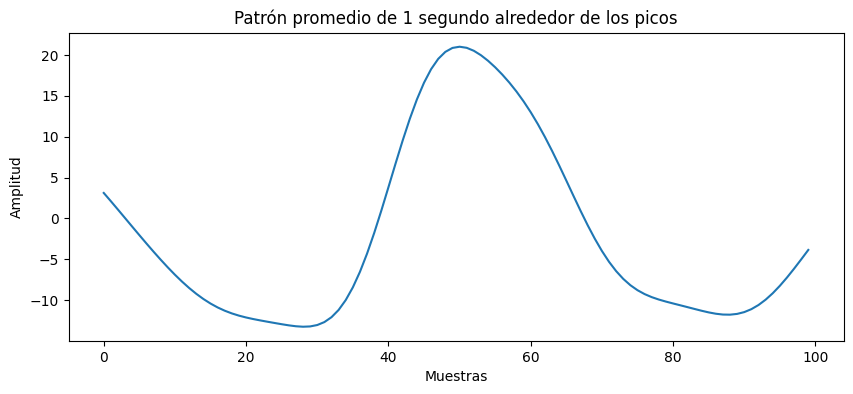

In [345]:
# segments = arrays de forma (n_segmentos, 100)
# cada fila = 1 segmento de 1 segundo (100 muestras) 
plantilla = np.mean(segments, axis=0) #axis=0 promedia cada columna, resultado = vector de 100 muestras representando el patrón promedio de 1 segundo alrededor de los picos

#visualizamos cómo luce el latido "ideal"
plt.figure(figsize=(10, 4))
plt.plot(plantilla)
plt.title("Patrón promedio de 1 segundo alrededor de los picos")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.show()

In [346]:
# segments: array (n_segmentos, 100)
# plantilla: vector de 100 puntos

cosine_sim = []
threshold = 0.85
filtered_segments = []

for seg in segments:
    # Calculamos similitud coseno
    sim = np.dot(seg, plantilla) / (np.linalg.norm(seg) * np.linalg.norm(plantilla)) #producto punto entre el producto de las magnitudes de los vectores
    cosine_sim.append(sim)
    
    # Filtramos
    if sim >= threshold:
        filtered_segments.append(seg)

filtered_segments = np.array(filtered_segments) #estos son los segmentos que pasaron el filtro de similitud coseno con la plantilla 
print(f"Número de segmentos que pasaron el filtro ≥ {threshold*100}%: {filtered_segments.shape[0]}")

Número de segmentos que pasaron el filtro ≥ 85.0%: 1217


In [347]:
n_segments = filtered_segments.shape[0] #número de segmentos que pasaron el filtro de similitud coseno

#creamos vectores de etiquetas y características con el mismo número de filas que los segmentos filtrados
bgl_values = np.full((n_segments,), fila_piloto['bgl_value_mg_dL'])
age_values = np.full((n_segments,), fila_piloto['age'])
sex_values = np.full((n_segments,), fila_piloto['sex'])
bmi_values = np.full((n_segments,), fila_piloto['bmi'])
caseid_values = np.full((n_segments,), fila_piloto['caseid'])
timestamp_values = np.full((n_segments,), fila_piloto['bgl_timestamp_sec'])

print("Segmentos filtrados:", filtered_segments.shape)
print("Etiquetas BGL:", bgl_values.shape)
print("Edad:", age_values.shape)
print("Sexo:", sex_values.shape)
print("BMI:", bmi_values.shape)

Segmentos filtrados: (1217, 100)
Etiquetas BGL: (1217,)
Edad: (1217,)
Sexo: (1217,)
BMI: (1217,)


In [348]:
# Verificar que las etiquetas son correctas
print("Primer valor BGL:", bgl_values[0])
print("Valor original:", fila_piloto['bgl_value_mg_dL'])
print("Primer age:", age_values[0])
print("Age original:", fila_piloto['age'])

Primer valor BGL: 154.0
Valor original: 154.0
Primer age: 77.0
Age original: 77.0


In [349]:
from pathlib import Path  

In [350]:
assert "filtered_segments" in globals(), "No existe filtered_segments. Ejecuta primero la segmentación."
assert filtered_segments.ndim == 2, "filtered_segments debe ser una matriz 2D."
assert filtered_segments.shape[1] == 100, "Cada segmento debe tener 100 muestras."
assert filtered_segments.shape[0] > 0, "No hay segmentos filtrados."

print("Forma de filtered_segments:", filtered_segments.shape)
print("Número de segmentos válidos:", filtered_segments.shape[0]) 
print("Número de muestras por segmento:", filtered_segments.shape[1])

Forma de filtered_segments: (1217, 100)
Número de segmentos válidos: 1217
Número de muestras por segmento: 100


In [351]:
ppg_cols = [f'ppg_{i}' for i in range(filtered_segments.shape[1])]

print("Número de columnas PPG:", len(ppg_cols))
print("Primeras columnas PPG:", ppg_cols[:5])
print("Últimas columnas PPG:", ppg_cols[-5:])

Número de columnas PPG: 100
Primeras columnas PPG: ['ppg_0', 'ppg_1', 'ppg_2', 'ppg_3', 'ppg_4']
Últimas columnas PPG: ['ppg_95', 'ppg_96', 'ppg_97', 'ppg_98', 'ppg_99']


In [352]:
pilot_dataset = pd.DataFrame(filtered_segments, columns=ppg_cols)
pilot_dataset['bgl_value_mg_dL'] = bgl_values
pilot_dataset['age'] = age_values
pilot_dataset['sex'] = sex_values
pilot_dataset['bmi'] = bmi_values
print("Dataset piloto creado con forma:", pilot_dataset.shape)

pilot_dataset.head()

Dataset piloto creado con forma: (1217, 104)


,ppg_0,ppg_1,ppg_2,ppg_3,ppg_4,ppg_5,ppg_6,ppg_7,ppg_8,ppg_9,...,ppg_94,ppg_95,ppg_96,ppg_97,ppg_98,ppg_99,bgl_value_mg_dL,age,sex,bmi
0,9.988499,8.169192,6.271562,4.322152,2.350923,0.391096,-1.521123,-3.347779,-5.052229,-6.603570,...,-13.765904,-12.226506,-10.259426,-7.882193,-5.140659,-2.109051,154.0,77.0,M,26.3
1,11.716134,9.685062,7.526645,5.275340,2.976525,0.684287,-1.542453,-3.645134,-5.570879,-7.276892,...,-11.642372,-10.238877,-8.481852,-6.374481,-3.938079,-1.214966,154.0,77.0,M,26.3
2,12.160035,10.438751,8.598714,6.657411,4.642615,2.591526,0.547328,-1.445654,-3.346392,-5.119863,...,-13.774793,-12.358490,-10.495850,-8.190840,-5.484901,-2.455108,154.0,77.0,M,26.3
3,11.295796,9.603103,7.746549,5.735628,3.598574,1.379214,-0.867880,-3.081911,-5.199903,-7.161156,...,-11.868113,-10.054984,-7.847623,-5.271756,-2.380991,0.743140,154.0,77.0,M,26.3
4,13.583217,12.023655,10.326315,8.490033,6.523593,4.449166,2.303935,0.138281,-1.989446,-4.019899,...,-12.932415,-11.402860,-9.425377,-7.017220,-4.226600,-1.131770,154.0,77.0,M,26.3


In [353]:
print("\nValores únicos en variables del paciente:")
print("Glucosa:", pilot_dataset["bgl_value_mg_dL"].nunique())
print("Edad:", pilot_dataset["age"].nunique())
print("Sexo:", pilot_dataset["sex"].nunique())
print("IMC:", pilot_dataset["bmi"].nunique())


Valores únicos en variables del paciente:
Glucosa: 1
Edad: 1
Sexo: 1
IMC: 1


In [354]:
print("Valores nulos en el dataset piloto:")
print(pilot_dataset.isna().sum()[pilot_dataset.isna().sum() > 0])

Valores nulos en el dataset piloto:
Series([], dtype: int64)


In [355]:
pilot_dataset['caseid'] = int(fila_piloto['caseid'])
pilot_dataset['bgl_timestamp_sec'] = float(fila_piloto['bgl_timestamp_sec'])

pilot_dataset.shape

(1217, 106)

In [356]:
pilot_dataset[
        ["caseid", "bgl_timestamp_sec", "bgl_value_mg_dL", "age", "sex", "bmi"]
    ].head()

,caseid,bgl_timestamp_sec,bgl_value_mg_dL,age,sex,bmi
0,1,3060.0,154.0,77.0,M,26.3
1,1,3060.0,154.0,77.0,M,26.3
2,1,3060.0,154.0,77.0,M,26.3
3,1,3060.0,154.0,77.0,M,26.3
4,1,3060.0,154.0,77.0,M,26.3


In [357]:
out_dir = Path("../data/processed/pilot") #directorio donde se guardará el dataset piloto
out_dir.mkdir(parents=True, exist_ok=True) #crea el directorio si no existe, con parents=True crea también los directorios padres si es necesario, exist_ok=True evita error si el directorio ya existe

caseid = int(fila_piloto["caseid"])
out_path = out_dir / f"pilot_dataset_case_{caseid}.csv"

pilot_dataset.to_csv(out_path, index=False)

print("Dataset piloto guardado en:")
print(out_path)

Dataset piloto guardado en:
..\data\processed\pilot\pilot_dataset_case_1.csv


In [358]:
df_pilot = pilot_dataset.copy()

ppg_cols = [col for col in df_pilot.columns if col.startswith('ppg_')]

X = df_pilot[ppg_cols].to_numpy(dtype=np.float32)
y = df_pilot['bgl_value_mg_dL'].to_numpy(dtype=np.float32)

print("Números de columnas PPG:", len(ppg_cols))
print("Números de filas en X:", X.shape[0])
print("Números de filas en y:", y.shape[0])

print("Primeras 5 filas de X:")
print(X[:5])
print("Primeras 5 etiquetas de y:")
print(y[:5])

Números de columnas PPG: 100
Números de filas en X: 1217
Números de filas en y: 1217
Primeras 5 filas de X:
[[  9.9885       8.169191     6.271562     4.3221517    2.350923
    0.39109588  -1.521123    -3.3477793   -5.052229    -6.6035705
   -7.980618    -9.173753   -10.184396   -11.022968   -11.706338
  -12.2553     -12.692227   -13.039108   -13.316398   -13.542888
  -13.7361145  -13.912365   -14.085574   -14.2651825  -14.453598
  -14.644096   -14.819769   -14.953911   -15.01165    -14.952216
  -14.731224   -14.302506   -13.619602   -12.637834   -11.317984
   -9.631584    -7.5669456   -5.1347837   -2.3721082    0.6569048
    3.8633091    7.1382823   10.360118    13.403714    16.152285
   18.509298    20.40785     21.815552    22.734335    23.195646
   23.252085    22.967184    22.40515     21.622112    20.660086
   19.544355    18.284473    16.878304    15.318131    13.59735
   11.716134     9.685061     7.526645     5.2753396    2.9765253
    0.6842866   -1.5424533   -3.6451342   -5.

In [359]:
print("\nValores únicos de y:")
print(np.unique(y))


Valores únicos de y:
[154.]


In [360]:
import torch

In [361]:
# Convertir a tensores de PyTorch
assert X.ndim == 2, "X debe ser una matriz 2D"
assert X.shape[1] == 100, "X debe tener 100 columnas (muestras de PPG)"
assert y.ndim == 1, "y debe ser un vector 1D"
assert X.shape[0] == y.shape[0], "X e y deben tener el mismo número de filas"

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_tensor = X_tensor.unsqueeze(1)  # Agregar dimensión de canal (n_samples, 1, 100)
y_tensor = y_tensor.view(-1,1)  # Asegurar que y_tensor es un vector columna (n_samples, 1)

print("Forma original de X", X.shape)
print("Forma de X_tensor", X_tensor.shape)

print("Forma original de y", y.shape)
print("Forma de y_tensor", y_tensor.shape)

Forma original de X (1217, 100)
Forma de X_tensor torch.Size([1217, 1, 100])
Forma original de y (1217,)
Forma de y_tensor torch.Size([1217, 1])


In [362]:
from torch.utils.data import Dataset, DataLoader

In [363]:
class PPGPilotDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x_i = self.X[idx]
        y_i = self.y[idx]
        return x_i, y_i

In [364]:
dataset_pilot = PPGPilotDataset(X_tensor, y_tensor)

print("Número de muestras en el dataset piloto:", len(dataset_pilot))

x_0, y_0 = dataset_pilot[0]

print("Forma de x_0:", x_0.shape)
print("Forma de y_0:", y_0.shape)
print("Valor de y_0:", y_0)

Número de muestras en el dataset piloto: 1217
Forma de x_0: torch.Size([1, 100])
Forma de y_0: torch.Size([1])
Valor de y_0: tensor([154.])


In [365]:
batch_size = 32

loader_pilot = DataLoader(dataset_pilot, batch_size=batch_size, shuffle=True)

print("Número de batches en el DataLoader:", len(loader_pilot))

X_batch, y_batch = next(iter(loader_pilot))

print("Forma de X_batch:", X_batch.shape)
print("Forma de y_batch:", y_batch.shape)

print("Primeros valores de y_batch:", y_batch[:5])

Número de batches en el DataLoader: 39
Forma de X_batch: torch.Size([32, 1, 100])
Forma de y_batch: torch.Size([32, 1])
Primeros valores de y_batch: tensor([[154.],
        [154.],
        [154.],
        [154.],
        [154.]])


In [366]:
import torch.nn as nn

In [367]:
class MiniCNN1D(nn.Module): #creación de una clase que hereda de nn.Module para definir la arquitectura de la red neuronal
    def __init__(self):
        super().__init__() #inicializa la clase nn.Module (siempre se inicializa así)

        self.conv1 = nn.Conv1d(in_channels=1, 
                               out_channels=8, 
                               kernel_size=3, 
                               padding=1)
        
        self.relu = nn.ReLU() #función de activación ReLU para introducir no linealidad

        self.pool = nn.AdaptiveAvgPool1d(1) #capa de pooling adaptativo que reduce la dimensión temporal a 1, promediando las características extraídas por la convolución  

        self.fc = nn.Linear(in_features=8, 
                            out_features=1) #capa totalmente conectada que toma las 8 características extraídas por la convolución y produce una salida de 1 valor (la predicción de glucosa)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.squeeze(-1) #elimina la dimensión de tamaño 1 al final, dejando un vector de características de tamaño (n_samples, 8)
        x = self.fc(x)
        return x

In [368]:
mini_model = MiniCNN1D()
print(mini_model)

MiniCNN1D(
  (conv1): Conv1d(1, 8, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


In [369]:
with torch.no_grad(): #desactiva el cálculo de gradientes para esta sección, ya que solo queremos hacer una pasada hacia adelante para verificar las formas de las salidas
    preds = mini_model(X_batch)

print("Forma de X_batch:", X_batch.shape)
print("Forma de preds:", preds.shape)
print("Forma de y_batch:", y_batch.shape)

print("\nPrimeras predicciones:")
print(preds[:5])

print("\nPrimeros valores reales:")
print(y_batch[:5])

Forma de X_batch: torch.Size([32, 1, 100])
Forma de preds: torch.Size([32, 1])
Forma de y_batch: torch.Size([32, 1])

Primeras predicciones:
tensor([[0.9160],
        [1.7138],
        [1.6819],
        [0.6981],
        [1.3171]])

Primeros valores reales:
tensor([[154.],
        [154.],
        [154.],
        [154.],
        [154.]])


In [370]:
#Calculamos la pérdida MSE entre las predicciones y los valores reales del batch actual
loss_fn = nn.MSELoss() #función de pérdida de error cuadrático medio, que mide la diferencia entre las predicciones y los valores reales, penalizando más las diferencias grandes

loss = loss_fn(preds, y_batch) 

print("MSE loss del batch actual:", loss.item())

MSE loss del batch actual: 23345.81640625


In [371]:
mini_model.eval() #pone el modelo en modo evaluación, desactivando comportamientos específicos de entrenamiento como dropout o batch normalization, para asegurar que las predicciones sean consistentes durante la evaluación

total_loss = 0
total_examples = 0

with torch.no_grad():
    for X_batch, y_batch in loader_pilot: #iteramos sobre todos los batches del DataLoader del dataset piloto
        preds = mini_model(X_batch)
        loss = loss_fn(preds, y_batch)

        batch_size_actual = X_batch.shape[0]

        total_loss += loss.item() * batch_size_actual #multiplicamos la pérdida promedio del batch por el número de ejemplos en el batch para obtener la pérdida total del batch, y sumamos a total_loss
        total_examples += batch_size_actual

avg_loss = total_loss / total_examples

print("Total de ejemplos evaluados:", total_examples)
print(f"Loss promedio en dataset piloto: {avg_loss:.2f}  ")

Total de ejemplos evaluados: 1217
Loss promedio en dataset piloto: 23320.22  


In [372]:
optimizer = torch.optim.Adam(mini_model.parameters(), lr=0.001)

mini_model.train()

optimizer.zero_grad() #reinicia los gradientes de todos los parámetros del modelo a cero, para evitar que se acumulen con los gradientes de iteraciones anteriores durante el proceso de entrenamiento

preds_before = mini_model(X_batch) 

loss_before = loss_fn(preds_before, y_batch)

loss_before.backward() #calcula los gradientes de la pérdida con respecto a los parámetros del modelo, almacenándolos en cada parámetro para que el optimizador pueda usarlos para actualizar los pesos

optimizer.step() #actualiza los pesos del modelo utilizando los gradientes calculados en el paso anterior, según el algoritmo de optimización Adam

mini_model.eval()

with torch.no_grad():
    preds_after = mini_model(X_batch)
    loss_after = loss_fn(preds_after, y_batch)

print(f"Loss después de entrenar un batch: {loss_before.item():.2f}")
print(f"Loss después de actualizar los pesos con el optimizador: {loss_after.item():.2f}")

Loss después de entrenar un batch: 23336.52
Loss después de actualizar los pesos con el optimizador: 23325.52


In [373]:
#entrenamos una época completa
#reiniciamos el modelo para empezar desde cero
mini_model = MiniCNN1D() 
optimizer = torch.optim.Adam(mini_model.parameters(), lr=0.001)

mini_model.train()

total_loss = 0
total_examples = 0

for X_batch, y_batch in loader_pilot:
    optimizer.zero_grad() 
    
    preds_before = mini_model(X_batch) 

    loss_before = loss_fn(preds_before, y_batch)

    loss_before.backward() 

    optimizer.step() 

    batch_size_actual = X_batch.shape[0]
    total_loss += loss_before.item() * batch_size_actual
    total_examples += batch_size_actual

avg_loss = total_loss / total_examples

print("Ejemplos entrenados:", total_examples)
print(f"Pérdida promedio en la época: {avg_loss:.2f}")

Ejemplos entrenados: 1217
Pérdida promedio en la época: 22924.98


In [374]:
#evaluamos el modelo después de entrenar una época completa
mini_model.eval()

total_loss_eval = 0
total_examples_eval = 0 
with torch.no_grad():
    for X_batch, y_batch in loader_pilot:
        preds_after = mini_model(X_batch)
        loss_after = loss_fn(preds_after, y_batch)

        batch_size_actual = X_batch.shape[0]
        total_loss_eval += loss_after.item() * batch_size_actual
        total_examples_eval += batch_size_actual

avg_loss_after = total_loss_eval / total_examples_eval

print("Ejemplos evaluados:", total_examples_eval)
print(f"Loss final después de entrenar una época completa: {avg_loss_after:.2f}")

Ejemplos evaluados: 1217
Loss final después de entrenar una época completa: 22627.90
